# ERpncoding


In [1]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Layer,  Softmax, Multiply, Add, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout, DepthwiseConv2D
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(1)  # Prueba con 4, 2 o 1


In [2]:
layer_type_options = {
    0: 'Conv2D', 
    1: 'BatchNorm', 
    2: 'MaxPooling', 
    3: 'Dropout', 
    4: 'Dense', 
    5: 'Flatten',
    6: 'SelfAttention',  # Reemplazo de DepthwiseConv2D por Self-Attention
    7: 'DontCare',  
    8: 'Repetition'
}

stride_options = {0: 1, 1: 2}
dropout_options = {0: 0.2, 1: 0.3, 2: 0.4, 3: 0.5}
activation_options = {0: 'relu', 1: 'leaky_relu', 2: 'sigmoid', 3: 'tanh'}

# Función para codificar los parámetros de la capa
def encode_layer_params(layer_type_idx, param1=0, param2=0, param3=0):
    """
    Codifica una capa en una lista en función del tipo de capa y sus parámetros.
    
    layer_type_idx : int : índice del tipo de capa según layer_type_options.
    param1         : int/float : filtros, neuronas, capas de repetición, etc.
    param2         : int : stride, número de repeticiones, etc.
    param3         : int : índice de activación o tasa de dropout.
    """
    return [layer_type_idx, param1, param2, param3]

def decode_layer_params(encoded_params):
    """
    Decodifica una capa desde su representación codificada en parámetros interpretables.
    
    encoded_params : list : [tipo de capa, param1, param2, param3].
    """
    layer_type_idx = encoded_params[0]
    layer_type = layer_type_options.get(layer_type_idx, 'DontCare')
    
    # Decodificar en función del tipo de capa
    if layer_type == 'Conv2D':
        filters = max(4, min(encoded_params[1], 32))  # Limitar filtros entre 4 y 32
        strides = stride_options.get(encoded_params[2], 1)
        activation = activation_options.get(encoded_params[3], 'relu')
        return {
            'type': 'Conv2D',
            'filters': filters,
            'strides': strides,
            'activation': activation
        }
    elif layer_type == 'BatchNorm':
        return {'type': 'BatchNorm'}
    elif layer_type == 'MaxPooling':
        strides = stride_options.get(encoded_params[1], 1)
        return {'type': 'MaxPooling', 'strides': strides}
    elif layer_type == 'Dropout':
        rate = dropout_options.get(encoded_params[1], 0.2)
        return {'type': 'Dropout', 'rate': rate}
    elif layer_type == 'Dense':
        units = max(1, min(encoded_params[1], 512))  # Limitar unidades entre 1 y 512
        activation = activation_options.get(encoded_params[2], 'relu')
        return {'type': 'Dense', 'units': units, 'activation': activation}
    elif layer_type == 'Flatten':
        return {'type': 'Flatten'}
    elif layer_type == 'Repetition':
        return {
            'type': 'Repetition',
            'repetition_layers': int(encoded_params[1]),
            'repetition_count': int(encoded_params[2])
        }
    elif layer_type == 'SelfAttention':
        filters = max(4, min(encoded_params[1], 64))  # Atención con 4-64 filtros
        attention_heads = max(1, min(encoded_params[2], 8))  # Máximo 8 cabezas de atención
        activation = activation_options.get(encoded_params[3], 'relu')  # Activación opcional
        return {
            'type': 'SelfAttention',
            'filters': filters,
            'attention_heads': attention_heads,
            'activation': activation
        }
    elif layer_type == 'DontCare':
        return {'type': "DontCare"}

    return None




# %% [markdown]
# ## Complete archs
# 

# %%


class SelfAttention(nn.Module):
    def __init__(self, filters, window_size=8, attention_heads=4, activation=nn.ReLU(), verbose=False):
        super(SelfAttention, self).__init__()
        if filters % attention_heads != 0:
            if verbose:
                print(f"Warning: {filters} no es divisible por {attention_heads}. Ajustando filters.")
            filters = filters - (filters % attention_heads)
            filters = max(filters, attention_heads)

        self.filters = filters
        self.attention_heads = attention_heads
        self.window_size = window_size
        self.verbose = verbose
        self.d_head = self.filters // self.attention_heads  # Canales por cabeza
        
        # Inicializar convoluciones como None para configurarlas en forward()
        self.query_conv = None
        self.key_conv = None
        self.value_conv = None
        self.projection_conv = None

    def forward(self, x):
        B, C, H, W = x.shape
        ws = min(self.window_size, H, W)  # Asegurar que `window_size` no sea mayor que H o W
        
        # Padding si H o W no son múltiplos de window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
            H, W = x.shape[2], x.shape[3]
        
        num_windows_h = H // ws
        num_windows_w = W // ws
        x_windows = x.view(B, C, num_windows_h, ws, num_windows_w, ws)
        x_windows = x_windows.permute(0, 2, 4, 1, 3, 5).contiguous()
        windows = x_windows.view(-1, C, ws, ws)

        # Ajustar convoluciones dinámicamente
        if self.query_conv is None or self.query_conv.in_channels != C:
            self.query_conv = nn.Conv2d(in_channels=C, out_channels=self.filters, kernel_size=1).to(x.device)
            self.key_conv = nn.Conv2d(in_channels=C, out_channels=self.filters, kernel_size=1).to(x.device)
            self.value_conv = nn.Conv2d(in_channels=C, out_channels=self.filters, kernel_size=1).to(x.device)

        Q = self.query_conv(windows)
        K = self.key_conv(windows)
        V = self.value_conv(windows)

        B_w, C_w, H_w, W_w = Q.shape
        N = H_w * W_w
        Q = Q.view(B_w, self.attention_heads, self.d_head, N).permute(0, 1, 3, 2)
        K = K.view(B_w, self.attention_heads, self.d_head, N).permute(0, 1, 3, 2)
        V = V.view(B_w, self.attention_heads, self.d_head, N).permute(0, 1, 3, 2)

        attn = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn = F.softmax(attn, dim=-1)
        out_window = torch.matmul(attn, V)

        out_window = out_window.permute(0, 1, 3, 2).contiguous()

        # Validación antes de `view()`
        expected_elements_out = B * C * num_windows_h * ws * num_windows_w * ws
        actual_elements_out = out_window.numel()

        if expected_elements_out != actual_elements_out:
            print(f"⚠️ ERROR: Tamaño incompatible en `view()`")
            print(f"Esperado: {expected_elements_out}, Real: {actual_elements_out}")
            print(f"Forma de `out_window` antes de `view()`: {out_window.shape}")
            
            # Ajuste seguro
            out = out_window.reshape(B, C, -1, num_windows_w * ws)
        else:
            out = out_window.view(B, C, num_windows_h * ws, num_windows_w * ws)

        if pad_h > 0 or pad_w > 0:
            out = out[:, :, :H - pad_h, :W - pad_w]
        return out






# Capa de identidad (DontCareLayer)
class DontCareLayer(nn.Module):
    def __init__(self):
        super(DontCareLayer, self).__init__()

    def forward(self, x):
        return x

# %%
def encode_model_architecture(model_dict, max_alleles=48):
    """
    Codifica la arquitectura del modelo en una lista de valores con un máximo de `max_alleles`.
    Cada capa se codifica en función de sus parámetros.
    """
    encoded_layers = []
    total_alleles = 0

    for layer in model_dict['layers']:
        if layer['type'] == 'Repetition':  # Codificar capa de repetición
            encoded_layer = encode_layer_params(
                layer_type_idx=8,  # índice para 'Repetition'
                param1=layer.get('repetition_layers', 0),
                param2=layer.get('repetition_count', 1)
            )
        else:
            layer_type_idx = next(
                key for key, value in layer_type_options.items() if value == layer['type']
            )
            
            # Codificar parámetros específicos de cada tipo de capa
            if layer['type'] == 'Conv2D':  
                param1 = max(4, min(layer.get('filters', 8), 32))  # Limitar filtros dentro del rango [4, 32]
                param2 = next((key for key, value in stride_options.items() if value == layer.get('strides', 1.0)), 0)
                param3 = next((key for key, value in activation_options.items() if value == layer.get('activation', 'relu')), 0)
                encoded_layer = [layer_type_idx, param1, param2, param3]

            elif layer['type'] == 'SelfAttention':  # Reemplazo de DepthwiseConv2D por SelfAttention
                param1 = max(4, min(layer.get('filters', 8), 64))  # Limitar filtros dentro del rango [4, 64]
                param2 = max(1, min(layer.get('attention_heads', 1), 8))  # Número de cabezas de atención [1, 8]
                param3 = next((key for key, value in activation_options.items() if value == layer.get('activation', 'relu')), 0)
                encoded_layer = [layer_type_idx, param1, param2, param3]

            elif layer['type'] == 'Dense':
                param1 = max(1, min(layer.get('units', 1), 512))  # Limitar neuronas dentro del rango [1, 512]
                param2 = next((key for key, value in activation_options.items() if value == layer.get('activation', 'relu')), 0)
                encoded_layer = [layer_type_idx, param1, param2, 0]

            elif layer['type'] == 'MaxPooling':
                param1 = next((key for key, value in stride_options.items() if value == layer.get('strides', 1.0)), 0)
                encoded_layer = [layer_type_idx, param1, 0, 0]

            elif layer['type'] == 'Dropout':
                param1 = next((key for key, value in dropout_options.items() if value == layer.get('rate', 0.2)), 0)
                encoded_layer = [layer_type_idx, param1, 0, 0]

            elif layer['type'] == 'BatchNorm':
                encoded_layer = [layer_type_idx, 0, 0, 0]

            elif layer['type'] == 'Flatten':
                encoded_layer = [layer_type_idx, 0, 0, 0]

            elif layer['type'] == 'DontCare':
                encoded_layer = [layer_type_idx, 0, 0, 0]

        # Añadir la codificación de la capa a la lista de alelos
        encoded_layers.extend(encoded_layer)
        total_alleles += len(encoded_layer)

    # Rellenar con 'DontCare' si el total de alelos es menor que `max_alleles`
    while total_alleles < max_alleles:
        dont_care_encoding = encode_layer_params(7)  # índice de 'DontCare'
        encoded_layers.extend(dont_care_encoding)
        total_alleles += len(dont_care_encoding)

    # Recortar si excede `max_alleles`
    final_encoding = encoded_layers[:max_alleles]
    #print(f"Final Encoded Model: {final_encoding}")
    
    return final_encoding


# %%


def fixArch(encoded_model, verbose=False):
    """
    Corrige la arquitectura codificada del modelo, asegurando que:
      - No se permitan capas incompatibles después de una capa Dense.
      - Se ajuste el alcance de repetición en caso de una capa Repetition.
      - Solo se permita una única capa SelfAttention, y se ajusten sus parámetros para que los filtros sean divisibles por attention_heads.
    
    Parameters:
      encoded_model (list): Lista codificada de la arquitectura del modelo.
      verbose (bool): Si es True, muestra mensajes de corrección.

    Returns:
      list: Lista con la arquitectura corregida, truncada a un máximo de 48 alelos.
    """
    
    fixed_layers = []         # Lista que almacenará la arquitectura corregida
    input_is_flattened = False # Indicador de que ya se aplicó una capa Flatten
    dense_started = False      # Indicador de que ya se encontró una capa Dense
    index = 0                  # Índice para recorrer el encoding
    found_self_attention = False  # Flag para asegurar que solo se use una SelfAttention

    while index < len(encoded_model) and len(fixed_layers) < 48:
        layer_type = int(encoded_model[index])  # Tipo de capa actual

        # Si ya se ha encontrado una Dense, solo se permiten Dense, BatchNorm o DontCare
        if dense_started and layer_type not in [4, 1, 7]:
            if verbose:
                print(f"Se encontró una capa de tipo {layer_type} después de una Dense, reemplazando con DontCare")
            fixed_layers.extend([7, 0, 0, 0])
            index += 4
            continue

        # Procesar capa de Repetition
        if layer_type == 8:
            repetition_layers = int(encoded_model[index + 1])
            repetition_count = min(max(int(encoded_model[index + 2]), 0), 32)
            actual_layers_to_repeat = min(repetition_layers, len(fixed_layers) // 4)
            if actual_layers_to_repeat != repetition_layers:
                if verbose:
                    print(f"Ajustando alcance de repetición de {repetition_layers} a {actual_layers_to_repeat} debido a falta de capas.")
                repetition_layers = actual_layers_to_repeat
            fixed_layers.extend([layer_type, repetition_layers, repetition_count, 0])
            index += 4
            continue

        # Procesar capas según su tipo
        if layer_type == 0:  # Conv2D
            if input_is_flattened:
                fixed_layers.extend([7, 0, 0, 0])  # Reemplazar con DontCare
            else:
                filters = min(max(int(encoded_model[index + 1]), 4), 32)
                stride_idx = min(max(int(encoded_model[index + 2]), 0), 1)
                activation_idx = min(max(int(encoded_model[index + 3]), 0), 3)
                fixed_layers.extend([layer_type, filters, stride_idx, activation_idx])

        elif layer_type == 6:  # SelfAttention
            if input_is_flattened or found_self_attention:
                fixed_layers.extend([7, 0, 0, 0])
                if verbose and found_self_attention:
                    print("Capa SelfAttention adicional reemplazada con DontCare.")
            else:
                filters = min(max(int(encoded_model[index + 1]), 4), 64)
                attention_heads = min(max(int(encoded_model[index + 2]), 1), 4)
                activation_idx = min(max(int(encoded_model[index + 3]), 0), 3)
                # Ajuste: Asegurar que 'filters' sea divisible por 'attention_heads'
                if filters % attention_heads != 0:
                    nuevo_valor = filters - (filters % attention_heads)
                    if verbose:
                        print(f"Warning: SelfAttention filters {filters} no es divisible por attention_heads {attention_heads}. Ajustando filters a {nuevo_valor}")
                    filters = nuevo_valor if nuevo_valor >= 4 else 4
                fixed_layers.extend([layer_type, filters, attention_heads, activation_idx])
                found_self_attention = True

        elif layer_type == 2:  # MaxPooling
            if input_is_flattened:
                fixed_layers.extend([7, 0, 0, 0])
            else:
                stride_idx = min(max(int(encoded_model[index + 1]), 0), 1)
                fixed_layers.extend([layer_type, stride_idx, 0, 0])

        elif layer_type == 3:  # Dropout
            rate_idx = min(max(int(encoded_model[index + 1]), 0), 3)
            fixed_layers.extend([layer_type, rate_idx, 0, 0])

        elif layer_type == 4:  # Dense
            neurons = min(max(int(encoded_model[index + 1]), 1), 512)
            activation_idx = min(max(int(encoded_model[index + 2]), 0), 3)
            fixed_layers.extend([layer_type, neurons, activation_idx, 0])
            dense_started = True

        elif layer_type == 1:  # BatchNorm
            if len(fixed_layers) > 0:
                prev_layer = fixed_layers[-4:]
                prev_layer_type = prev_layer[0]
                if prev_layer_type in [0, 6]:
                    num_features = prev_layer[1]
                else:
                    num_features = 4
            else:
                num_features = 4
            if verbose:
                print(f"Configurando BatchNorm con {num_features} canales")
            fixed_layers.extend([layer_type, num_features, 0, 0])

        elif layer_type == 5:  # Flatten
            if input_is_flattened or dense_started:
                fixed_layers.extend([7, 0, 0, 0])
            else:
                if index + 4 < len(encoded_model):
                    next_layer_type = int(encoded_model[index + 4])
                    if next_layer_type not in [4, 7]:  # Flatten debería ir seguido de Dense o DontCare
                        if verbose:
                            print(f"Warning: Flatten seguido de {next_layer_type}, reemplazando con DontCare")
                        fixed_layers.extend([7, 0, 0, 0])
                    else:
                        fixed_layers.extend([layer_type, 0, 0, 0])
                        input_is_flattened = True
                else:
                    fixed_layers.extend([layer_type, 0, 0, 0])
                    input_is_flattened = True

        elif layer_type == 7:  # DontCare
            fixed_layers.extend([layer_type, 0, 0, 0])

        else:  # Tipo desconocido
            fixed_layers.extend([7, 0, 0, 0])

        index += 4

    return fixed_layers[:48]



# %%
def decode_model_architecture(encoded_model):
    """
    Decodifica la arquitectura del modelo a partir de la lista codificada de valores (índices),
    aplicando las reglas de repetición y asegurando la inclusión de una capa convolucional inicial.
    """
    model_dict = {'layers': []}  # Lista de capas decodificadas
    index = 0
    found_self_attention = False  # Flag para asegurar una sola SelfAttention

    while index < len(encoded_model):
        layer_type = int(encoded_model[index])
        param1 = encoded_model[index + 1]
        param2 = encoded_model[index + 2]
        param3 = encoded_model[index + 3]

        if layer_type == 8:  # Capa de Repetition
            repetition_layers = int(param1)
            repetition_count = int(param2)

            # Selecciona solo capas válidas para la repetición (sin incluir SelfAttention)
            layers_to_repeat = select_group_for_repetition(model_dict['layers'], repetition_layers)

            if len(layers_to_repeat) > 0:
                for _ in range(repetition_count):
                    for layer in layers_to_repeat:
                        # Si la capa es SelfAttention, reemplazarla con DontCare
                        if layer['type'] == 'SelfAttention':
                            model_dict['layers'].append({'type': 'DontCare'})
                        else:
                            model_dict['layers'].append(layer)

        else:
            decoded_layer = {}

            if layer_type == 0:  # Conv2D
                decoded_layer = {
                    'type': 'Conv2D',
                    'filters': max(4, min(param1, 32)),  # Limita `filters` entre 4 y 32
                    'strides': stride_options.get(param2, 1),
                    'activation': activation_options.get(param3, 'relu')
                }
            elif layer_type == 6:  # SelfAttention
                if found_self_attention:  # Si ya hay una SelfAttention, la ignoramos
                    index += 4
                    continue
                decoded_layer = {
                    'type': 'SelfAttention',
                    'filters': max(4, min(param1, 64)),  # Limita `filters` entre 4 y 64
                    'attention_heads': max(1, min(param2, 4)),  # Limita `attention_heads` entre 1 y 4
                    'activation': activation_options.get(param3, 'relu')
                }
                found_self_attention = True  # Marca que ya se agregó una SelfAttention
            elif layer_type == 2:  # MaxPooling
                decoded_layer = {
                    'type': 'MaxPooling',
                    'strides': stride_options.get(param1, 1)
                }
            elif layer_type == 3:  # Dropout
                decoded_layer = {
                    'type': 'Dropout',
                    'rate': dropout_options.get(param1, 0.2)
                }
            elif layer_type == 4:  # Dense
                decoded_layer = {
                    'type': 'Dense',
                    'units': max(1, min(param1, 512)),  # Limita `units` entre 1 y 512
                    'activation': activation_options.get(param2, 'relu')
                }
            elif layer_type == 1:  # BatchNorm
                decoded_layer = {'type': 'BatchNorm'}
            elif layer_type == 5:  # Flatten
                decoded_layer = {'type': 'Flatten'}
            elif layer_type == 7:  # DontCare
                decoded_layer = {'type': 'DontCare'}

            model_dict['layers'].append(decoded_layer)

        index += 4

    # Asegura que haya una capa Flatten antes de la capa Dense final, si no ya existe una Flatten
    if model_dict['layers'][-1]['type'] != 'Flatten':
        model_dict['layers'].append({'type': 'Flatten'})
        
    # Añade la capa Dense final obligatoria
    model_dict['layers'].append({'type': 'Dense', 'units': 1, 'activation': 'sigmoid'})

    return model_dict


def select_group_for_repetition(layers, repetition_layers):
    """
    Selecciona el primer grupo válido para repetición en función de las reglas de compatibilidad,
    evitando la duplicación de SelfAttention.

    Parameters:
        layers (list): Lista de capas ya procesadas, donde cada capa es un diccionario.
        repetition_layers (int): Número de capas hacia atrás para considerar en la repetición.

    Returns:
        list: Lista de capas compatibles para repetición, sin SelfAttention.
    """
    valid_layers = []
    group_type = None

    # Retrocede desde el final de `layers` para encontrar el grupo válido
    for layer in reversed(layers[-repetition_layers:]):
        if group_type is None:
            # Determina el tipo de grupo
            if layer['type'] in ['Flatten', 'Dense']:
                group_type = 'dense'
                valid_layers.insert(0, layer)
            elif layer['type'] in ['Conv2D', 'SelfAttention', 'MaxPooling']:
                group_type = 'convolutional'
                valid_layers.insert(0, layer)
            elif layer['type'] in ['BatchNorm', 'DontCare']:  # BatchNorm y DontCare son compatibles con ambos grupos
                valid_layers.insert(0, layer)
        else:
            # Agrega solo capas compatibles con el grupo seleccionado
            if group_type == 'dense' and layer['type'] in ['Flatten', 'Dense', 'BatchNorm', 'DontCare']:
                valid_layers.insert(0, layer)
            elif group_type == 'convolutional' and layer['type'] in ['Conv2D', 'SelfAttention', 'MaxPooling', 'BatchNorm', 'DontCare']:
                valid_layers.insert(0, layer)

    return valid_layers

class BuildPyTorchModel(nn.Module):
    def __init__(self, model_dict, input_shape=(1, 64, 552), verbose=False):
        """
        Construye un modelo de PyTorch a partir de un diccionario de arquitectura.
        """
        super(BuildPyTorchModel, self).__init__()
        self.verbose = verbose
        model_dict = decode_model_architecture(model_dict)

        target_in_channels = 4  # Número mínimo de canales requeridos en la arquitectura
        layers = []
        if input_shape[0] != target_in_channels:
            if self.verbose:
                print(f"📌 Insertando capa de conversión: de {input_shape[0]} canal(es) a {target_in_channels} canales.")
            self.initial_conv = nn.Conv2d(in_channels=input_shape[0],
                                          out_channels=target_in_channels,
                                          kernel_size=1)
            in_channels = target_in_channels
        else:
            self.initial_conv = None
            in_channels = input_shape[0]

        self.linear_layers = []

        for layer in model_dict['layers']:
            if layer['type'] == 'Conv2D':
                layers.append(nn.Conv2d(in_channels=in_channels,
                                        out_channels=layer['filters'],
                                        kernel_size=3,
                                        stride=layer['strides'],
                                        padding=1))
                layers.append(nn.ReLU() if layer['activation'] == "relu" else nn.LeakyReLU())
                in_channels = layer['filters']
            elif layer['type'] == 'SelfAttention':
                layers.append(SelfAttention(filters=in_channels,
                                            attention_heads=layer['attention_heads'],
                                            activation=layer['activation'],
                                            verbose=self.verbose))
            elif layer['type'] == 'BatchNorm':
                # Se inicia con BatchNorm2d, pero se ajustará en forward si es necesario.
                layers.append(nn.BatchNorm2d(in_channels))
            elif layer['type'] == 'MaxPooling':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=layer['strides'], padding=1))
            elif layer['type'] == 'Flatten':
                layers.append(nn.Flatten())
            elif layer['type'] == 'Dense':
                self.linear_layers.append((layer['units'], layer['activation']))
            elif layer['type'] == 'Dropout':
                layers.append(nn.Dropout(p=layer['rate']))
            elif layer['type'] == 'DontCare':
                layers.append(DontCareLayer())

        self.feature_extractor = nn.Sequential(*layers)

    def forward(self, x):
        if self.initial_conv is not None:
            x = self.initial_conv(x)

        for i, module in enumerate(self.feature_extractor):
            # Si el módulo es BatchNorm2d pero la entrada es 2D (después del Flatten)
            if isinstance(module, nn.BatchNorm2d):
                if x.dim() == 2:  # Es decir, (batch, features)
                    num_features = x.shape[1]
                    print(f"⚠️ Reemplazando BatchNorm2d por BatchNorm1d para entrada con forma {x.shape}")
                    # Reemplazar la capa por una BatchNorm1d con el número correcto de features
                    self.feature_extractor[i] = nn.BatchNorm1d(num_features).to(x.device)
                    module = self.feature_extractor[i]
                else:
                    # En caso de entrada 4D, se verifica que el número de canales coincida
                    num_channels = x.shape[1]
                    if module.num_features != num_channels:
                        print(f"⚠️ Ajustando BatchNorm2d: esperaba {module.num_features} canales, pero recibió {num_channels}")
                        self.feature_extractor[i] = nn.BatchNorm2d(num_channels).to(x.device)
                        module = self.feature_extractor[i]
            x = module(x)

        # Construcción dinámica de capas densas
        if not hasattr(self, "fully_connected"):
            in_features = x.shape[1]
            fc_layers = []
            for units, activation in self.linear_layers:
                fc_layers.append(nn.Linear(in_features, units))
                fc_layers.append(nn.ReLU() if activation == "relu" else nn.LeakyReLU())
                in_features = units
            self.fully_connected = nn.Sequential(*fc_layers).to(x.device)

        x = self.fully_connected(x)
        return x




In [3]:
import csv
import numpy as np
from pyDOE2 import lhs

# Función para generar un hipercubo latino con rangos normalizados [0, 1]
def generate_latin_hypercube_samples(num_samples, dimensions):
    return lhs(dimensions, samples=num_samples)

# Validar si los parámetros generados están dentro del rango esperado
def validate_latin_hypercube(num_models=100):
    dimensions = 12 * 3  # 12 capas, 3 parámetros por capa
    latin_samples = generate_latin_hypercube_samples(num_models, dimensions)
    
    # Validar cada muestra generada
    for sample_idx, sample in enumerate(latin_samples):
        reshaped_sample = sample.reshape(12, 3)  # Cada modelo tiene 12 capas
        
        for layer_idx, layer_params in enumerate(reshaped_sample):
            type_idx = int(layer_params[0] * 9)  # 9 tipos de capas
            param1 = layer_params[1]
            param2 = layer_params[2]

            layer_mapping = ['Conv2D', 'SelfAttention', 'BatchNorm', 'MaxPooling', 
                             'Dropout', 'Dense', 'Flatten', 'DontCare', 'Repetition']
            layer_type = layer_mapping[type_idx]

            if layer_type == 'Conv2D':
                filters = int(param1 * (32 - 4) + 4)  # Filtros entre [4, 32]
                if not (4 <= filters <= 32):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Filtros fuera de rango {filters}")
                    return False

            elif layer_type == 'SelfAttention':
                filters = int(param1 * (64 - 4) + 4)  # Filtros entre [4, 64]
                attention_heads = int(param2 * (8 - 1) + 1)  # Heads entre [1, 8]
                if not (4 <= filters <= 64) or not (1 <= attention_heads <= 8):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Parámetros fuera de rango")
                    return False

            elif layer_type == 'Dropout':
                rate = param1 * (0.5 - 0.2) + 0.2  # Tasa de dropout entre [0.2, 0.5]
                if not (0.2 <= rate <= 0.5):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Dropout fuera de rango {rate}")
                    return False

            elif layer_type == 'Dense':
                units = int(param1 * (512 - 1) + 1)  # Unidades entre [1, 512]
                if not (1 <= units <= 512):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Unidades fuera de rango {units}")
                    return False

    print("Validación completada: Todas las muestras están dentro de los rangos esperados.")
    return True

# Guardar el encoding generado en un archivo CSV
def save_encoded_models_to_csv(num_models, filename, max_alleles=48):
    latin_samples = generate_latin_hypercube_samples(num_models, 12 * 3)  # 12 capas, 3 parámetros por capa

    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Model", "Encoded Chromosome"])

        for model_idx in range(num_models):
            model_samples = latin_samples[model_idx].reshape(12, 3)

            model_dict = {
                "layers": [
                    map_to_architecture_params(sample) for sample in model_samples
                ]
            }

            encoded_chromosome = fixArch(encode_model_architecture(model_dict, max_alleles=max_alleles))
            writer.writerow([model_idx + 1, encoded_chromosome])

    print(f"Cromosomas codificados guardados en {filename}")

# Mapear valores normalizados a arquitecturas
def map_to_architecture_params(latin_hypercube_sample):
    layer_type = int(latin_hypercube_sample[0] * 9)  # 9 tipos de capas
    layer_mapping = ['Conv2D', 'SelfAttention', 'BatchNorm', 'MaxPooling', 
                     'Dropout', 'Dense', 'Flatten', 'DontCare', 'Repetition']

    layer_type_name = layer_mapping[layer_type]

    if layer_type_name == 'Conv2D':
        return {
            "type": "Conv2D",
            "filters": int(latin_hypercube_sample[1] * (32 - 4) + 4),  # [4, 32]
            "strides": 1 if latin_hypercube_sample[2] < 0.5 else 2,
            "activation": "relu"
        }
    elif layer_type_name == 'SelfAttention':  # Reemplazo de DepthwiseConv2D
        return {
            "type": "SelfAttention",
            "filters": int(latin_hypercube_sample[1] * (64 - 4) + 4),  # [4, 64]
            "attention_heads": int(latin_hypercube_sample[2] * (8 - 1) + 1),  # [1, 8]
            "activation": "relu"
        }
    elif layer_type_name == 'BatchNorm':
        return {"type": "BatchNorm"}
    elif layer_type_name == 'MaxPooling':
        return {"type": "MaxPooling", "strides": 1 if latin_hypercube_sample[1] < 0.5 else 2}
    elif layer_type_name == 'Dropout':
        return {"type": "Dropout", "rate": latin_hypercube_sample[1] * (0.5 - 0.2) + 0.2}
    elif layer_type_name == 'Dense':
        return {
            "type": "Dense",
            "units": int(latin_hypercube_sample[1] * (512 - 1) + 1),
            "activation": "relu"
        }
    elif layer_type_name == 'Flatten':
        return {"type": "Flatten"}
    elif layer_type_name == 'DontCare':
        return {"type": "DontCare"}
    elif layer_type_name == 'Repetition':
        return {
            "type": "Repetition",
            "repetition_layers": int(latin_hypercube_sample[1] * 3 + 1),
            "repetition_count": int(latin_hypercube_sample[2] * 2 + 1)
        }
    return {}

# Ejecutar validación y guardado en CSV
""" if validate_latin_hypercube(num_models=5000):
    save_encoded_models_to_csv(num_models=5000, filename="EncodedChromosomes_V3.csv")
 """

' if validate_latin_hypercube(num_models=5000):\n    save_encoded_models_to_csv(num_models=5000, filename="EncodedChromosomes_V3.csv")\n '

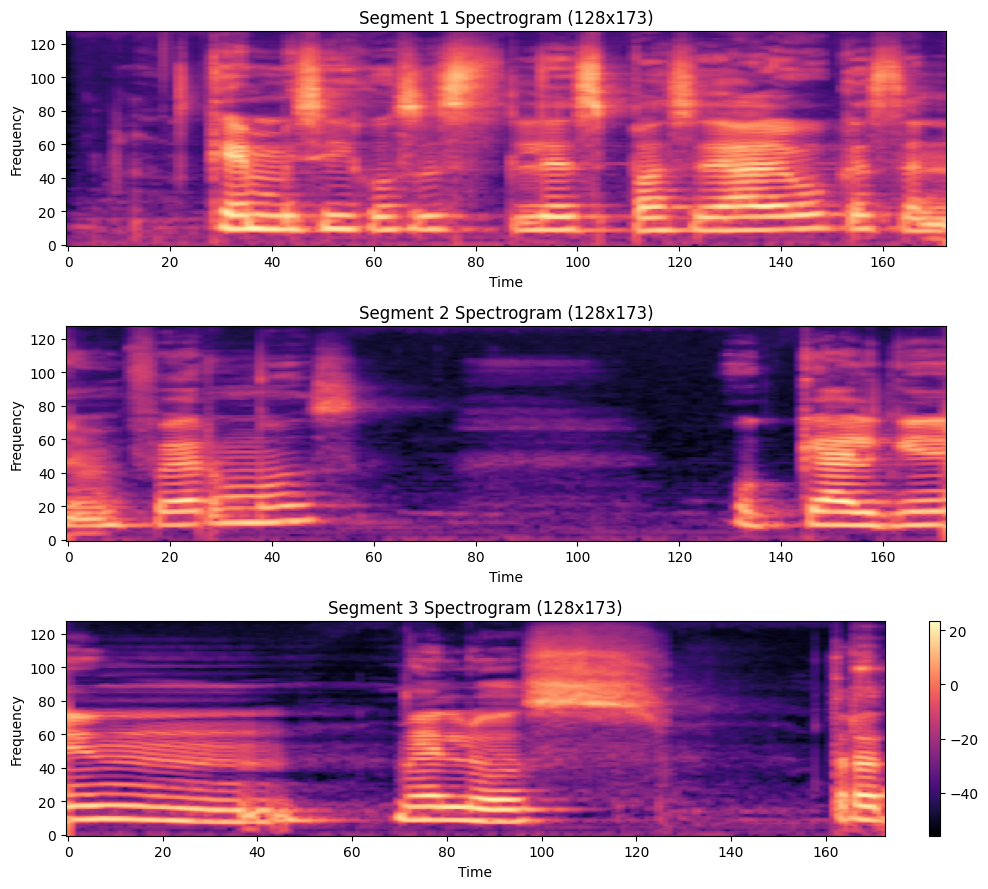

In [4]:
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import numpy as np

def load_audio_and_split(file_path, segment_duration=2.0):
    """
    Carga un archivo de audio y lo divide en fragmentos de segment_duration segundos.
    """
    waveform, sample_rate = torchaudio.load(file_path)

    # Calcular el número total de muestras por segmento
    segment_samples = int(segment_duration * sample_rate)
    total_samples = waveform.shape[1]

    # Dividir el audio en segmentos de 2 segundos
    audio_segments = []
    for start in range(0, total_samples, segment_samples):
        end = start + segment_samples
        if end > total_samples:
            break  # Evita fragmentos incompletos
        audio_segments.append(waveform[:, start:end])

    return audio_segments, sample_rate

def generate_mel_spectrogram(audio_segment, sample_rate, n_mels=128, n_fft=2048, hop_length=512):
    """
    Genera un espectrograma de Mel a partir de un fragmento de audio.
    """
    mel_transform = T.MelSpectrogram(
        sample_rate=sample_rate,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )
    mel_spec = mel_transform(audio_segment)

    # Convertir a escala logarítmica (dB)
    mel_spec = torchaudio.functional.amplitude_to_DB(mel_spec, multiplier=10.0, amin=1e-10, db_multiplier=0.0)
    
    return mel_spec

def plot_spectrograms(audio_segments, sample_rate, n_mels=128):
    """
    Genera y muestra los espectrogramas de todos los fragmentos de audio.
    """
    num_segments = len(audio_segments)
    fig, axes = plt.subplots(num_segments, 1, figsize=(10, 3 * num_segments))

    if num_segments == 1:
        axes = [axes]  # Asegurar que siempre sea iterable

    for i, segment in enumerate(audio_segments):
        mel_spec = generate_mel_spectrogram(segment, sample_rate, n_mels=n_mels)
        mel_spec_np = mel_spec.squeeze(0).numpy()  # Remove the first dimension

        ax = axes[i]
        img = ax.imshow(mel_spec_np, origin="lower", aspect="auto", cmap="magma")
        ax.set_title(f"Segment {i+1} Spectrogram ({mel_spec_np.shape[0]}x{mel_spec_np.shape[1]})")
        ax.set_xlabel("Time")
        ax.set_ylabel("Frequency")

    plt.colorbar(img, ax=axes[-1], orientation='vertical', fraction=0.02)
    plt.tight_layout()
    plt.show()

# Ruta del archivo de audio
file_path = "./SM-27/001_10.wav"  # Cambia esto por el archivo que estás usando

# Cargar y fragmentar el audio en segmentos de 2 segundos
audio_segments, sample_rate = load_audio_and_split(file_path, segment_duration=2.0)

# Mostrar los espectrogramas de todos los segmentos
plot_spectrograms(audio_segments, sample_rate, n_mels=128)


In [5]:
import os
import json
import pandas as pd
import torchaudio

def create_balanced_subset(directory, dataset_csv, window_size, output_file):
    df = pd.read_csv(dataset_csv, usecols=['Participant_ID', 'PHQ-9 Score'])
    df['label'] = (df['PHQ-9 Score'] >= 10).astype(int)
    labels = df.set_index('Participant_ID')['label'].to_dict()

    audio_data = {"depressed": [], "non_depressed": []}

    for file_name in os.listdir(directory):
        if file_name.endswith(".wav"):
            participant_id = int(file_name.split("_")[0].split('.')[0])
            if participant_id not in labels:
                print(f"ID de participante no encontrado en dataset: {participant_id}")
                continue
            
            label = "depressed" if labels[participant_id] == 1 else "non_depressed"
            waveform, sr = torchaudio.load(os.path.join(directory, file_name))

            # Definir el tamaño mínimo de muestras requerido para un fragmento de `window_size` segundos
            min_samples = window_size * sr
            total_samples = waveform.shape[1]

            if total_samples < min_samples:
                # ⚠️ Omitir audios demasiado cortos
                print(f"⚠️ OMITIENDO: {file_name} - Duración insuficiente ({total_samples/sr:.2f} s)")
                continue  # Pasar al siguiente archivo

            # ✅ Fragmentar en segmentos de `window_size` segundos
            num_windows = total_samples // min_samples
            for i in range(num_windows):
                start = i * min_samples
                end = (i + 1) * min_samples
                segment = waveform[:, start:end].numpy()
                audio_data[label].append((file_name, i, segment.tolist()))

    # Balancear las clases
    min_samples = min(len(audio_data["depressed"]), len(audio_data["non_depressed"]))
    balanced_subset = {
        "depressed": audio_data["depressed"][:min_samples],
        "non_depressed": audio_data["non_depressed"][:min_samples]
    }

    # Guardar en JSON
    with open(output_file, "w") as f:
        json.dump(balanced_subset, f)

    print(f"📌 Subconjunto equilibrado guardado en {output_file}")


# Entrenando el modelo surogado


In [1]:
import os
import numpy as np
import pandas as pd
import torchaudio
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
    
from torch.utils.data import TensorDataset, DataLoader

import json


# Configuración de parámetros
class Config:
    def __init__(self, epochs=20, window_size=2, sample_rate=None, checkpoint_file="checkpoint_surr.json"):
        self.epochs = epochs
        self.window_size = window_size
        self.sample_rate = sample_rate
        self.checkpoint_file = checkpoint_file

# 📌 Dataset personalizado para cargar audios en tiempo de ejecución
class AudioDataset(Dataset):
    def __init__(self, directory, dataset_csv, window_size):
        self.directory = directory
        self.window_size = window_size
        self.audio_segments = self._load_audio_segments(dataset_csv)

    def _load_audio_segments(self, dataset_csv):
        """Carga los nombres de los archivos y sus etiquetas desde el CSV, dividiendo en segmentos de `window_size` segundos."""
        df = pd.read_csv(dataset_csv, usecols=['Participant_ID', 'PHQ-9 Score'])
        df['label'] = (df['PHQ-9 Score'] >= 10).astype(int)
        labels = df.set_index('Participant_ID')['label'].to_dict()

        audio_segments = []

        for file_name in os.listdir(self.directory):
            if file_name.endswith(".wav"):
                participant_id = int(file_name.split("_")[0].split('.')[0])
                if participant_id not in labels:
                    continue

                label = labels[participant_id]
                file_path = os.path.join(self.directory, file_name)
                waveform, sample_rate = torchaudio.load(file_path)

                min_samples = self.window_size * sample_rate
                total_samples = waveform.shape[1]

                if total_samples < min_samples:
                    print(f"⚠️ OMITIENDO: {file_name} - Duración insuficiente ({total_samples/sample_rate:.2f} s)")
                    continue

                num_windows = total_samples // min_samples  # 🔹 Dividir en segmentos de `window_size`
                for i in range(num_windows):
                    start = i * min_samples
                    end = start + min_samples
                    segment = waveform[:, start:end]
                    audio_segments.append((segment, label))

        return audio_segments

    def __len__(self):
        return len(self.audio_segments)

    def __getitem__(self, idx):
        waveform, label = self.audio_segments[idx]
        spectrogram = self._generate_spectrogram(waveform)
        return spectrogram, label
    
    def _generate_spectrogram(self, waveform):
        """Convierte audio en espectrograma Mel y lo normaliza."""
        n_mels = 64
        sample_rate = 16000  # Aseguramos que sea consistente
        n_fft = int(sample_rate * 0.029)
        hop_length = int(sample_rate * 0.010)
        win_length = int(sample_rate * 0.025)

        spec = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            n_mels=n_mels,
            hop_length=hop_length,
            win_length=win_length
        )(waveform)

        spec = torchaudio.transforms.AmplitudeToDB()(spec)
        spec = (spec - spec.min()) / (spec.max() - spec.min())

        return torch.tensor(spec.squeeze(0), dtype=torch.float32)
    
# 📌 Mostrar los dos primeros espectrogramas generados
def show_first_two_spectrograms(dataset):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for i in range(2):
        spec, label = dataset[i]
        axes[i].imshow(spec.numpy(), origin="lower", aspect="auto", cmap="magma")
        axes[i].set_title(f"Espectrograma {i+1} - Label: {label}")
    plt.show()


def save_checkpoint(file_path, architecture_index):
    """
    Guarda el checkpoint con la última arquitectura completada.

    Args:
        file_path (str): Ruta donde se guarda el checkpoint.
        architecture_index (int): Índice de la última arquitectura entrenada.
    """
    checkpoint = {"last_completed": architecture_index}
    with open(file_path, 'w') as f:
        json.dump(checkpoint, f)
    print(f"📌 Checkpoint guardado: {checkpoint}")

def load_checkpoint(file_path):
    """
    Carga el checkpoint guardado para continuar el entrenamiento desde la última arquitectura.

    Args:
        file_path (str): Ruta del archivo de checkpoint.

    Returns:
        dict: Diccionario con el índice de la última arquitectura entrenada.
    """
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            checkpoint = json.load(f)
            return checkpoint
    return {"last_completed": -1}  # Si no hay checkpoint, empezar desde el inicio

import csv

# 📌 Función para guardar resultados en CSV
def save_results_to_csv(file_path, architecture, results):
    """
    Guarda los resultados de la arquitectura en un archivo CSV.
    
    Parameters:
        - file_path (str): Ruta del archivo CSV donde se guardarán los resultados.
        - architecture (list): Representación codificada de la arquitectura.
        - results (list): Métricas del modelo (loss, accuracy, precision, recall, f1, specificity).
    """
    columns = ["Encoded Architecture", "Loss", "Accuracy", "Precision", "Recall", "F1", "Specificity"]

    # 📌 Si el archivo no existe, crear con encabezados
    if not os.path.exists(file_path):
        with open(file_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(columns)

    # 📌 Escribir los resultados
    with open(file_path, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([str(architecture)] + results)  # Guardar arquitectura y métricas
    
    print(f"📊 Resultados guardados en {file_path}")



def train_models(csv_path_architectures, dataset_csv, directory, epochs=20, batch_size=32, save_file="results.csv",
                 verbose=False):
    print("📌 Iniciando entrenamiento de modelos...")

    config = Config(epochs=epochs)
    checkpoint = load_checkpoint(config.checkpoint_file)

    print("📌 Cargando y procesando audios en tiempo de ejecución...")
    dataset = AudioDataset(directory, dataset_csv, config.window_size)
    print(f"📌 Total de muestras cargadas: {len(dataset)}")
    dataset = [d for d in dataset if d is not None]  # ⚠️ Filtrar valores `None`

    print(f"📌 Total de muestras antes del balanceo: {len(dataset)}")

    # 🔹 Balanceo de clases: cortar al tamaño de la clase minoritaria
    spectrograms, labels = zip(*dataset)  # Extraer espectrogramas y etiquetas
    spectrograms = torch.stack(spectrograms)  # Convertir a tensor
    labels = torch.tensor(labels)

    # 🔹 Contar muestras por clase
    num_class_0 = (labels == 0).sum().item()
    num_class_1 = (labels == 1).sum().item()
    min_class_count = min(num_class_0, num_class_1)  # Tamaño de la clase minoritaria

    print(f"📊 Cantidad de muestras por clase antes del balanceo:")
    print(f"   🔹 Clase 0 (No Depresión): {num_class_0}")
    print(f"   🔹 Clase 1 (Depresión): {num_class_1}")
    print(f"   📌 Ajustando ambas clases a {min_class_count} muestras.")

    # 🔹 Seleccionar aleatoriamente la misma cantidad de muestras de cada clase
    idx_class_0 = torch.where(labels == 0)[0][:min_class_count]
    idx_class_1 = torch.where(labels == 1)[0][:min_class_count]
    balanced_indices = torch.cat((idx_class_0, idx_class_1))

    spectrograms = spectrograms[balanced_indices]
    labels = labels[balanced_indices]

    print(f"📌 Total de muestras después del balanceo: {spectrograms.shape[0]}")

    # 🔹 Dividir en train/val/test con random_state=42 para reproducibilidad
    print("📌 Dividiendo datos en conjuntos de entrenamiento, validación y prueba...")
    X_train, X_test, Y_train, Y_test = train_test_split(spectrograms, labels, test_size=0.2, stratify=labels, random_state=42)
    X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, stratify=Y_train, random_state=42)

    print(f"📊 Tamaño de los conjuntos después del balanceo:")
    print(f"   🔹 Train: {X_train.shape[0]}")
    print(f"   🔹 Validation: {X_val.shape[0]}")
    print(f"   🔹 Test: {X_test.shape[0]}")

    # 🔹 Crear DataLoaders sin shuffle (manteniendo el orden para checkpoints)
    print("📌 Creando DataLoaders...")
    train_loader = DataLoader(TensorDataset(X_train.unsqueeze(1), Y_train), batch_size=batch_size,num_workers=0)
    val_loader = DataLoader(TensorDataset(X_val.unsqueeze(1), Y_val), batch_size=batch_size, num_workers=0)
    test_loader = DataLoader(TensorDataset(X_test.unsqueeze(1), Y_test), batch_size=batch_size,num_workers=0)

    print("📌 Mostrando dos espectrogramas de ejemplo...")
    show_first_two_spectrograms(dataset)

    # 🔹 Obtener `input_shape` automáticamente del primer batch
    example_batch, _ = next(iter(train_loader))
    example_batch = example_batch.unsqueeze(1)  # 🔹 Añadir dimensión de canal
    input_shape = example_batch.shape[1:]  # Extraer shape sin batch_size
    print(f"📌 Input shape corregido automáticamente: {input_shape}")


    architectures = load_architectures_from_csv(csv_path_architectures)
    print(f"📌 Total de arquitecturas a evaluar: {len(architectures)}")

    for i, architecture in enumerate(architectures):
        if i <= checkpoint["last_completed"]:
            print(f"⏭️ Saltando arquitectura {i+1}/{len(architectures)} (ya entrenada)...")
            continue  # Saltar arquitecturas ya completadas

        print(f"\n🚀 Evaluando arquitectura {i + 1}/{len(architectures)}...")

        # 📌 Construcción del modelo
        model = BuildPyTorchModel(architecture, input_shape=input_shape, verbose=verbose)
        model.to(dtype=torch.float32)  # Forzar que use float32 en vez de bfloat16

        print("📌 Modelo construido. Iniciando entrenamiento...")

        # 📌 Entrenar y evaluar modelo
        results = train_and_evaluate_model(model, train_loader, val_loader, test_loader, config)

        # 📌 Guardar resultados en CSV
        save_results_to_csv(save_file, architecture, results)

        # 📌 Guardar checkpoint
        print(f"📌 Arquitectura {i+1} evaluada con éxito. Guardando checkpoint...")
        save_checkpoint(config.checkpoint_file, i)
    print("✅ Entrenamiento completado con éxito.")


from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 📌 Función para calcular F1-score, precisión, recall y especificidad
def calculate_metrics(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # 📌 Calcular la especificidad
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return precision, recall, f1, specificity


# 📌 Entrenar y evaluar modelo
def train_and_evaluate_model(model, train_loader, val_loader, test_loader, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"📌 Entrenando en: {device}")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    print("📌 Iniciando entrenamiento...")

    for epoch in range(config.epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)  # 🔹 Asegurar que `labels` sea float

            optimizer.zero_grad()

            outputs = model(inputs).squeeze()  # 🔹 Convertir [batch_size, 1] → [batch_size]
            loss = criterion(outputs, labels)  # 📌 Ahora las formas coinciden

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"🔹 Epoch [{epoch+1}/{config.epochs}] - Loss: {running_loss/len(train_loader):.4f}")

    print("📌 Entrenamiento finalizado. Evaluando en test...")

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)

            outputs = model(inputs).squeeze()
            predictions = (torch.sigmoid(outputs) > 0.5).int()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    accuracy = (np.array(y_true) == np.array(y_pred)).mean()
    precision, recall, f1, specificity = calculate_metrics(y_true, y_pred)

    return [running_loss / len(train_loader), accuracy, precision, recall, f1, specificity]



    return accuracy

# 📌 Calcular métricas
def calculate_f1_score(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=1)
    recall = recall_score(y_true, y_pred, zero_division=1)
    f1 = f1_score(y_true, y_pred, zero_division=1)

    print(f"📊 Resultados de Evaluación:")
    print(f"  - Precision: {precision:.4f}")
    print(f"  - Recall: {recall:.4f}")
    print(f"  - F1-Score: {f1:.4f}")

    return precision, recall, f1

# 📌 Cargar arquitecturas desde CSV
def load_architectures_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    architectures = df['Encoded Chromosome'].apply(lambda x: [int(i) for i in x.strip("[]").split(",")])
    return architectures.tolist()

""" train_models("EncodedChromosomes_V3.csv", "Dataset.csv", "./SM-27",
             save_file="EncodedChromosomes_V3_results.csv", verbose=False, batch_size=1) """


' train_models("EncodedChromosomes_V3.csv", "Dataset.csv", "./SM-27",\n             save_file="EncodedChromosomes_V3_results.csv", verbose=False, batch_size=1) '

## Revisando distribucion del dataset


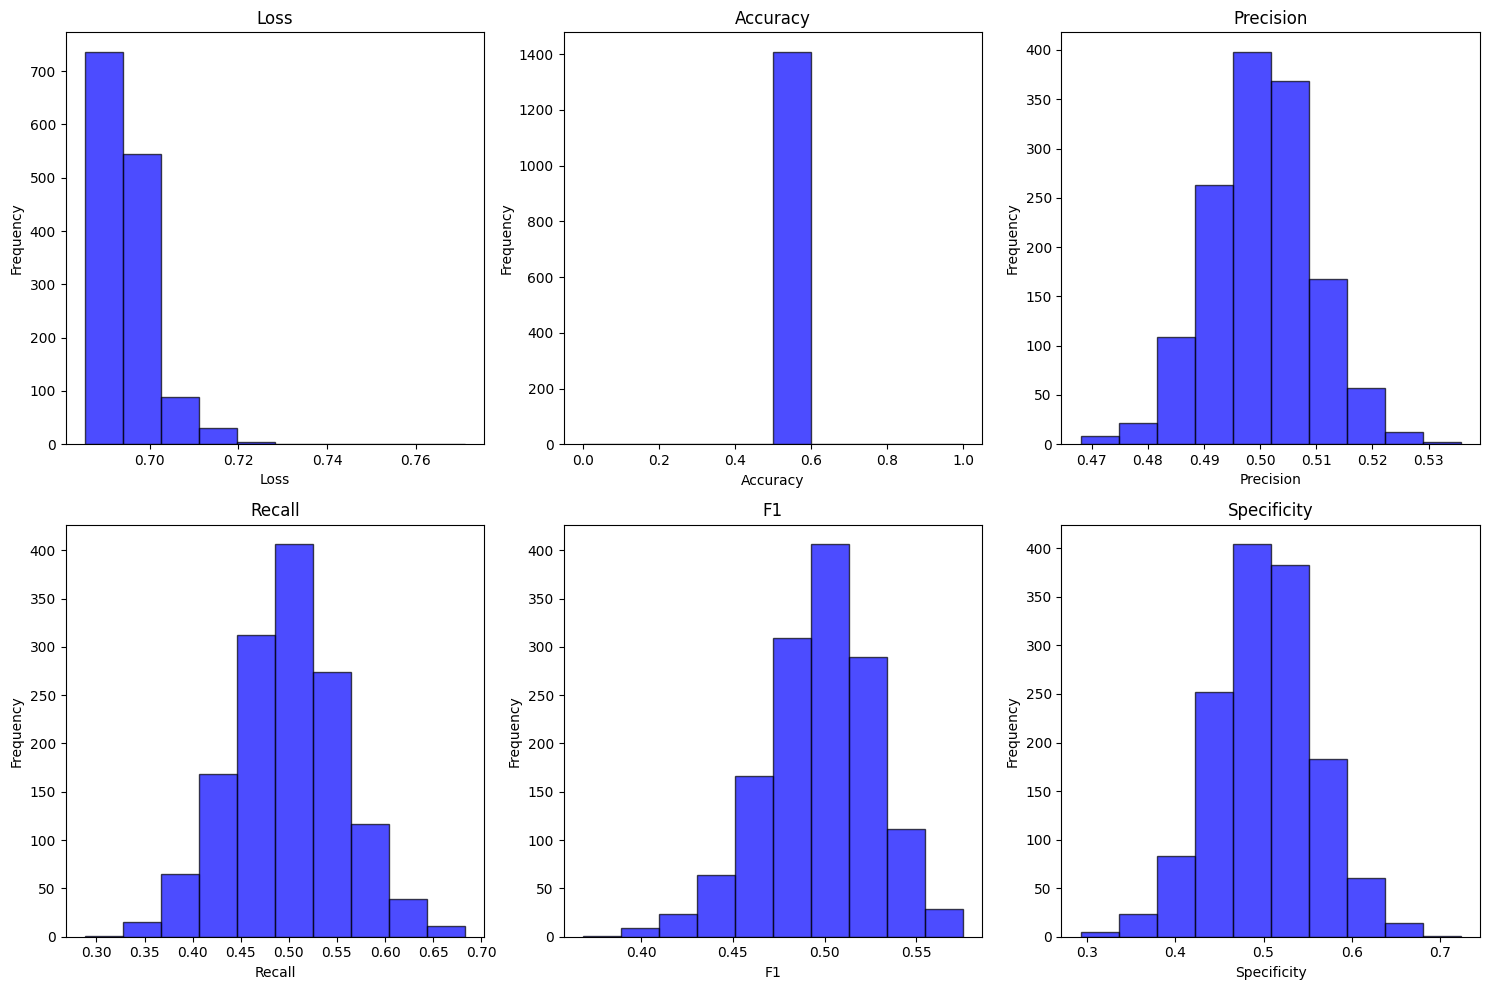

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset desde el archivo CSV
file_path = './EncodedChromosomes_V3_results.csv'
df = pd.read_csv(file_path)

# Especificar las métricas a graficar
metrics = ["Loss", "Accuracy", "Precision", "Recall", "F1", "Specificity"]

# Crear un único plot con subplots para cada métrica
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

for i, metric in enumerate(metrics):
    row, col = divmod(i, 3)
    axes[row, col].hist(df[metric], bins=10, alpha=0.7, color="blue", edgecolor="black")
    axes[row, col].set_title(metric)
    axes[row, col].set_xlabel(metric)
    axes[row, col].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# Creación del modelo


## XGBoostB y SVM


1408

🔹 Entrenando XGBoost para F1 Score...
✅ Modelo guardado en ./surrogates_v2\F1_XGBoost_optimized.pkl

🔹 Entrenando SVM para F1 Score...
✅ Modelo guardado en ./surrogates_v2\F1_SVM_optimized.pkl

🔹 Entrenando CatBoost para F1 Score...
✅ Modelo guardado en ./surrogates_v2\F1_CatBoost_optimized.pkl

🔹 Entrenando RandomForest para F1 Score...
✅ Modelo guardado en ./surrogates_v2\F1_RandomForest_optimized.pkl
Epoch 1/500
13/18 [====================>.........] - ETA: 0s - loss: 1.5020 - mae: 0.9871
Epoch 1: val_loss improved from inf to 0.27801, saving model to ./surrogates_v2\DeepNN_model.h5
18/18 [==============================] - 1s 14ms/step - loss: 1.4018 - mae: 0.9489 - val_loss: 0.2780 - val_mae: 0.5066
Epoch 2/500
14/18 [======================>.......] - ETA: 0s - loss: 1.0621 - mae: 0.8081
Epoch 2: val_loss did not improve from 0.27801
18/18 [==============================] - 0s 6ms/step - loss: 1.0343 - mae: 0.8018 - val_loss: 0.3543 - val_mae: 0.5748
Epoch 3/500
13/18 [======

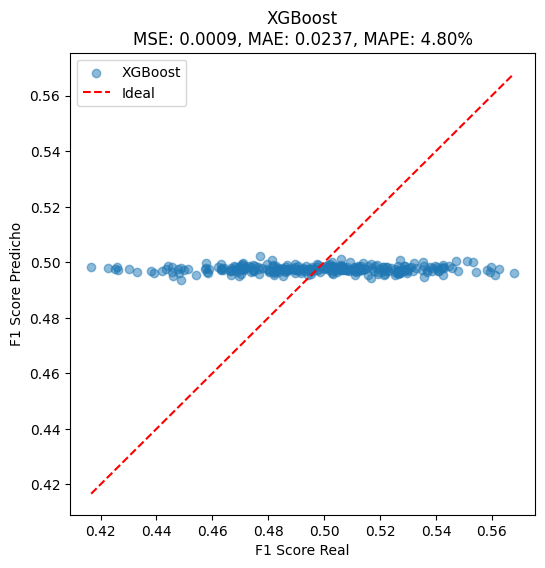

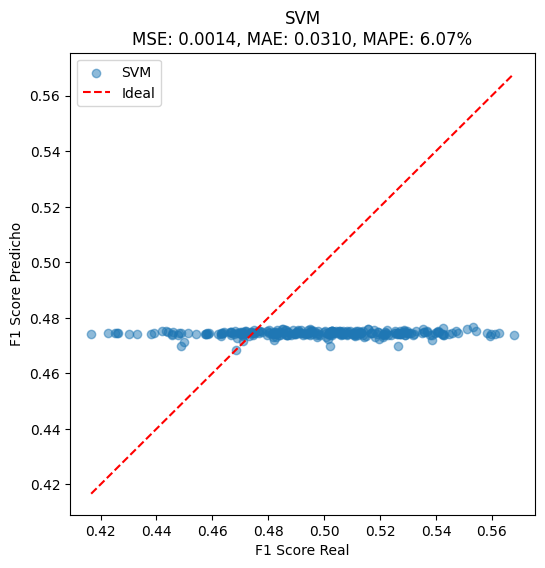

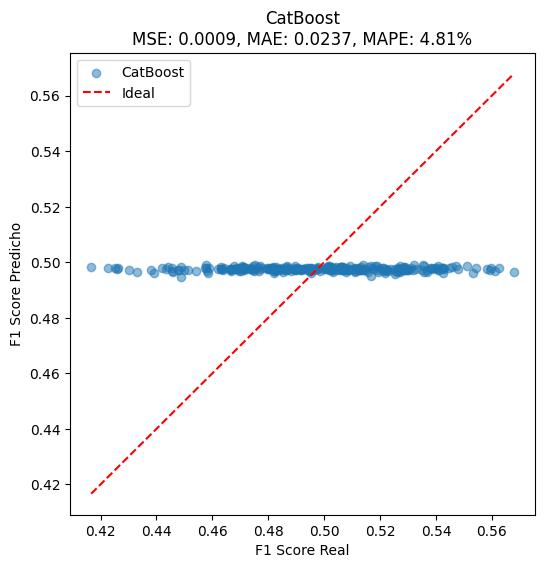

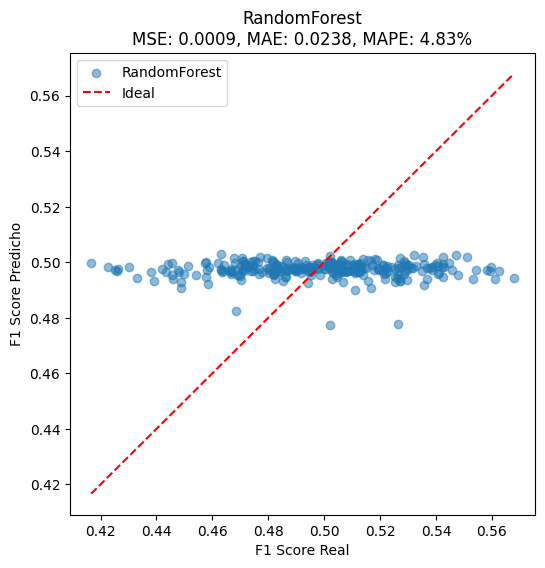

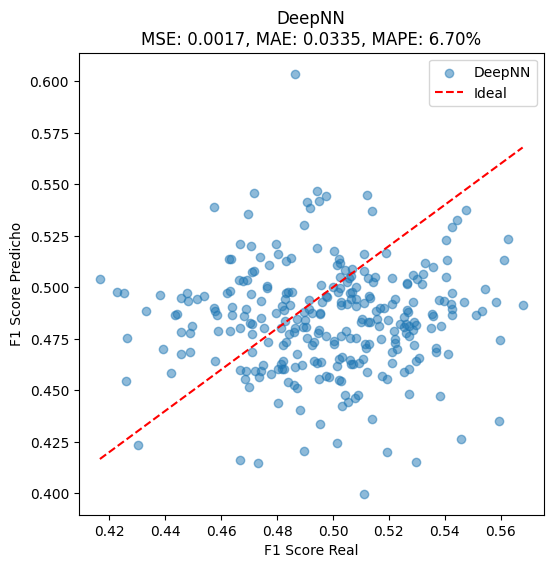

In [15]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ===============================
# 📌 Cargar y preparar los datos
# ===============================
file_path = "./EncodedChromosomes_V3_results.csv"
data = pd.read_csv(file_path)

# Convertir 'Encoded Architecture' en listas de enteros
data['Encoded Architecture'] = data['Encoded Architecture'].apply(eval)

# Expandir 'Encoded Architecture' en múltiples columnas
X = pd.DataFrame(data['Encoded Architecture'].tolist())

# Normalizar los datos de entrada
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Métrica objetivo (solo F1 Score)
y = data[['F1']]
print(len(y))

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ===============================
# 📌 Modelos de scikit-learn
# ===============================
# Espacios de búsqueda de hiperparámetros
param_grids = {
    'XGBoost': {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['linear', 'rbf']
    },
    'CatBoost': {
        'iterations': [50, 100],
        'depth': [3, 5],
        'learning_rate': [0.01, 0.1]
    },
    'RandomForest': {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    }
}

# Modelos a entrenar
models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    'SVM': SVR(),
    'CatBoost': CatBoostRegressor(silent=True),
    'RandomForest': RandomForestRegressor()
}

# Diccionario para almacenar resultados
results = {}

# Función para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-10))) * 100

# Directorio de salida
output_dir = "./surrogates_v2"
os.makedirs(output_dir, exist_ok=True)

# Función para entrenar y evaluar modelos de scikit-learn
def train_and_evaluate(model, param_grid, model_name):
    print(f"\n🔹 Entrenando {model_name} para F1 Score...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train['F1'])
    best_model = grid_search.best_estimator_
    
    # Predicciones y métricas
    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test['F1'], y_pred)
    mae = mean_absolute_error(y_test['F1'], y_pred)
    mape = mean_absolute_percentage_error(y_test['F1'], y_pred)
    
    results[model_name] = {
        'Best Params': grid_search.best_params_,
        'Test MSE': mse,
        'Test MAE': mae,
        'Test MAPE': mape
    }
    
    # Guardar modelo en formato .pkl
    model_path = os.path.join(output_dir, f"F1_{model_name}_optimized.pkl")
    joblib.dump(best_model, model_path)
    print(f"✅ Modelo guardado en {model_path}")
    
    return y_pred, mse, mae, mape

# Entrenar modelos tradicionales
predictions = {}
metrics = {}

for name, model in models.items():
    predictions[name], mse, mae, mape = train_and_evaluate(model, param_grids[name], name)
    metrics[name] = (mse, mae, mape)

# ===============================
# 📌 Modelo DeepNN con TensorFlow/Keras
# ===============================
input_dim = X_train.shape[1]
tf.random.set_seed(42)

# Definir la arquitectura del modelo
deep_model = Sequential([
    Dense(128, input_dim=input_dim, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

# Compilar el modelo
deep_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                   loss='mse',
                   metrics=['mae'])

# Definir callbacks: EarlyStopping y ModelCheckpoint para guardar el mejor modelo en formato .h5
checkpoint_path = os.path.join(output_dir, "DeepNN_model.h5")
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

# Entrenar el modelo DeepNN
history = deep_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=500,
    batch_size=64,
    callbacks=[early_stop, model_checkpoint],
    verbose=1
)

# El modelo se guarda automáticamente en checkpoint_path ("DeepNN_model.h5")
print(f"✅ Modelo DeepNN guardado en {checkpoint_path}")

# Evaluar DeepNN
loss, mae_val = deep_model.evaluate(X_test, y_test, verbose=0)
y_pred_nn = deep_model.predict(X_test).flatten()
mse_nn = mean_squared_error(y_test['F1'], y_pred_nn)
mae_nn = mean_absolute_error(y_test['F1'], y_pred_nn)
mape_nn = mean_absolute_percentage_error(y_test['F1'], y_pred_nn)
predictions["DeepNN"] = y_pred_nn
metrics["DeepNN"] = (mse_nn, mae_nn, mape_nn)

print(f"DeepNN -> MSE: {mse_nn:.4f}, MAE: {mae_nn:.4f}, MAPE: {mape_nn:.2f}%")

# ===============================
# 📌 Generar gráficos individuales por modelo
# ===============================
for model_name, y_pred in predictions.items():
    mse_val, mae_val, mape_val = metrics[model_name]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_test, y_pred, alpha=0.5, label=model_name)
    ax.plot(
        [min(y_test.values), max(y_test.values)],
        [min(y_test.values), max(y_test.values)],
        'r--', label="Ideal"
    )
    ax.set_xlabel("F1 Score Real")
    ax.set_ylabel("F1 Score Predicho")
    ax.set_title(f"{model_name}\nMSE: {mse_val:.4f}, MAE: {mae_val:.4f}, MAPE: {mape_val:.2f}%")
    ax.legend()
    plt.show()


## Synflow


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 📌 Cargar los datos
file_path = "./EncodedChromosomes_V3_results.csv"
data = pd.read_csv(file_path)

# 📌 Verificar si SynFlow está en los datos
if 'SynFlow' not in data.columns:
    raise ValueError("⚠️ La columna 'SynFlow' no está en el archivo CSV.")

# 📌 Calcular la correlación de Pearson entre SynFlow y F1 Score
corr, p_value = pearsonr(data['SynFlow'], data['F1'])

print(f"📊 Correlación de Pearson entre SynFlow y F1 Score: {corr:.4f}")
print(f"📊 Valor p: {p_value:.4f}")

# 📌 Generar gráfico de dispersión con tendencia
plt.figure(figsize=(7, 5))
sns.scatterplot(x=data['SynFlow'], y=data['F1'], alpha=0.5)
sns.regplot(x=data['SynFlow'], y=data['F1'], scatter=False, color='red', label='Tendencia')
plt.xlabel("SynFlow")
plt.ylabel("F1 Score")
plt.title(f"Correlación SynFlow vs. F1 Score\nPearson: {corr:.4f}")
plt.legend()
plt.show()


ValueError: ⚠️ La columna 'SynFlow' no está en el archivo CSV.

📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 14 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 56 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 17 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
⚠️ Reemplazando BatchNorm2d por BatchNorm1d para entrada con forma torch.Size([1, 141312])
⚠️ Error en el modelo: Expected more than 1 value per channel when training, got input size torch.Size([1, 141312])
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 9 canales
📌 Configurando BatchNorm con 4 canales
📌 Configurando BatchNorm con 4 canales
📌 Configur

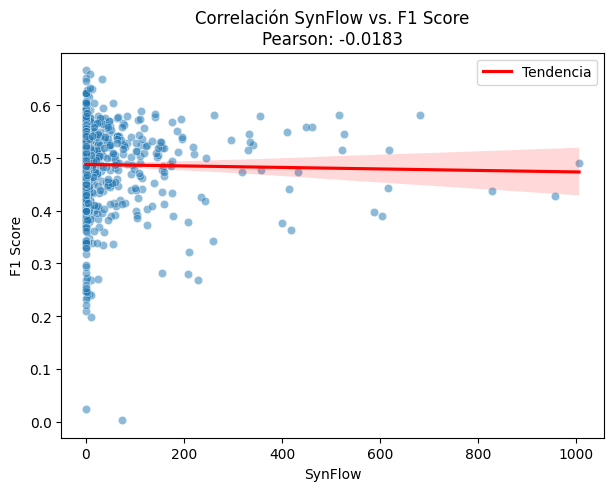

In [12]:
import torch
import torch.nn as nn
import pandas as pd
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Cargar el CSV con las arquitecturas
file_path = "./EncodedChromosomes_V3_results.csv"
data = pd.read_csv(file_path)

# 📌 Convertir 'Encoded Architecture' en listas de enteros
data['Encoded Architecture'] = data['Encoded Architecture'].apply(eval)

# 📌 Función para calcular SynFlow con corrección de gradientes
def compute_synflow(model):
    """
    Calcula la métrica SynFlow asegurando que todos los parámetros tengan gradientes.
    """
    model.eval()
    for p in model.parameters():
        p.requires_grad = True  # Habilitar gradientes para los pesos

    input_shape = (1, 1, 64, 552)  # Dimensión de entrada (1 canal, 64x552)
    input_data = torch.ones(input_shape, requires_grad=True)  # Hacer que la entrada también tenga gradientes
    
    # Asegurar que el modelo pueda manejar el input correctamente
    try:
        output = model(input_data)  # Pasar el input por la red
        loss = output.sum()  # Generar una suma de salida
        loss.backward(retain_graph=True)  # Retropropagación para obtener los gradientes
    except Exception as e:
        print(f"⚠️ Error en el modelo: {e}")
        return 0  # Si el modelo falla, devolver SynFlow = 0

    # Calcular SynFlow sumando |gradiente * peso| en cada parámetro del modelo
    synflow_score = sum((p.grad * p).abs().sum().item() if p.grad is not None else 0 for p in model.parameters())
    
    return synflow_score

# 📌 Calcular SynFlow para cada arquitectura
synflow_values = []
for arch in data['Encoded Architecture']:
    # Aplicar correcciones a la arquitectura
    encoded_fixed_arch = fixArch(arch)  
    # Construir el modelo en PyTorch
    pytorch_model = BuildPyTorchModel(encoded_fixed_arch)

    # Calcular SynFlow
    synflow_score = compute_synflow(pytorch_model)
    synflow_values.append(synflow_score)

# 📌 Agregar los valores de SynFlow al DataFrame
data['SynFlow'] = synflow_values

# 📌 Guardar el nuevo CSV con SynFlow incluido
data.to_csv("EncodedChromosomes_with_SynFlow.csv", index=False)
print("✅ SynFlow calculado y guardado en 'EncodedChromosomes_with_SynFlow.csv'")

# 📌 Calcular la correlación entre SynFlow y F1 Score
corr, p_value = pearsonr(data['SynFlow'], data['F1'])
print(f"📊 Correlación de Pearson entre SynFlow y F1 Score: {corr:.4f}")
print(f"📊 Valor p: {p_value:.4f}")

# 📌 Visualización de la correlación con un gráfico
plt.figure(figsize=(7, 5))
sns.scatterplot(x=data['SynFlow'], y=data['F1'], alpha=0.5)
sns.regplot(x=data['SynFlow'], y=data['F1'], scatter=False, color='red', label='Tendencia')
plt.xlabel("SynFlow")
plt.ylabel("F1 Score")
plt.title(f"Correlación SynFlow vs. F1 Score\nPearson: {corr:.4f}")
plt.legend()
plt.show()


# GA


In [9]:
def int_to_real_dom(num, domain):
    min_i, max_i = domain
    r = (num - min_i) / (max_i - min_i)
    return r

def real_to_int_dom(num, domain):
    min_i, max_i = domain
    value = min_i + num * (max_i - min_i)
    if isinstance(min_i, int) and isinstance(max_i, int):
        value = int(round(value))
    return value

def convert_individual(ind, to_real=True):
    real_rep = []
    N = max(layer_type_options.keys())  # Obtener el máximo índice de capa en el diccionario

    for i in range(0, len(ind), 4):
        layer_type_idx = ind[i]
        domain_layer_type = [0, N]
        
        if to_real:
            real_rep.append(int_to_real_dom(layer_type_idx, domain_layer_type))
            layer_type = layer_type_options.get(layer_type_idx, 'DontCare')
        else:
            real_rep.append(real_to_int_dom(layer_type_idx, domain_layer_type))
            layer_type = layer_type_options.get(real_rep[i], 'DontCare')

        # Decodificación basada en el tipo de capa
        if layer_type == 'Conv2D':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [4, 32]))  # Filtros
                real_rep.append(int_to_real_dom(ind[i + 2], [0, 1]))  # Stride
                real_rep.append(int_to_real_dom(ind[i + 3], [0, 3]))  # Activación
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [4, 32]))
                real_rep.append(real_to_int_dom(ind[i + 2], [0, 1]))
                real_rep.append(real_to_int_dom(ind[i + 3], [0, 3]))

        elif layer_type == 'SelfAttention':  # 🚀 Reemplazo de DepthwiseConv2D por SelfAttention
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [4, 64]))  # Filtros
                real_rep.append(int_to_real_dom(ind[i + 2], [1, 8]))  # Número de cabezas de atención
                real_rep.append(int_to_real_dom(ind[i + 3], [0, 3]))  # Activación
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [4, 64]))
                real_rep.append(real_to_int_dom(ind[i + 2], [1, 8]))
                real_rep.append(real_to_int_dom(ind[i + 3], [0, 3]))

        elif layer_type == 'BatchNorm':
            real_rep.extend([0, 0, 0])

        elif layer_type == 'MaxPooling':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [0, 1]))
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [0, 1]))
            real_rep.extend([0, 0])

        elif layer_type == 'Dropout':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [0, 3]))
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [0, 3]))
            real_rep.extend([0, 0])

        elif layer_type == 'Dense':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [1, 512]))  # Neuronas
                real_rep.append(int_to_real_dom(ind[i + 2], [0, 3]))  # Activación
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [1, 512]))
                real_rep.append(real_to_int_dom(ind[i + 2], [0, 3]))
            real_rep.append(0)

        elif layer_type == 'Flatten':
            real_rep.extend([0, 0, 0])

        elif layer_type == 'Repetition':
            if to_real:
                real_rep.append(int_to_real_dom(ind[i + 1], [1, 4]))  # Número de capas a repetir
                real_rep.append(int_to_real_dom(ind[i + 2], [1, 32]))  # Cantidad de repeticiones
            else:
                real_rep.append(real_to_int_dom(ind[i + 1], [1, 4]))
                real_rep.append(real_to_int_dom(ind[i + 2], [1, 32]))
            real_rep.append(0)

        elif layer_type == 'DontCare':
            real_rep.extend([0, 0, 0])

    return real_rep


In [10]:
import numpy as np

def get_succ_m(parents, children):
  # Count if mutation was successful than the average parent fitness
  parent_fitness = [parent['fitness'] for parent in parents]
  avg_fitness = np.mean(parent_fitness)

  succ_m_count = sum(1 for child in children if child['fitness'] < avg_fitness)

  return succ_m_count

In [11]:
import random
def get_cr_points(rp, n):
  indexes = list(range(n))
  j_star = random.sample(indexes, n // 2)

  for j in range(n):
    if random.random() < rp and j not in j_star:
      j_star.append(j)

  return j_star

In [12]:
def pop_gen(num_models, max_alleles=48):
    """
    Genera una población inicial utilizando el hipercubo latino y las funciones existentes.

    Args:
        num_models: int - Número de individuos a generar.
        max_alleles: int - Número máximo de alelos en los cromosomas.

    Returns:
        list - Lista de diccionarios con individuos y su fitness inicializado a 0.
    """
    archs = []
    dimensions = 12 * 3  # 12 capas, 3 parámetros por capa

    # Generar muestras del hipercubo latino
    latin_samples = generate_latin_hypercube_samples(num_models, dimensions)

    for sample in latin_samples:
        # Transformar cada muestra en una arquitectura
        model_samples = sample.reshape(12, 3)
        model_dict = {
            "layers": [map_to_architecture_params(layer_sample) for layer_sample in model_samples]
        }

        # Codificar el modelo y repararlo
        encoded_chromosome = encode_model_architecture(model_dict, max_alleles=max_alleles)
        repaired_architecture = fixArch(encoded_chromosome)

        # Añadir a la población
        archs.append({'individual': repaired_architecture, 'fitness': 0})

    return archs


In [13]:
from tqdm import tqdm

def es(target_func, mu=10, lamb=1, F=2, rp=0.5, gens=100, n=10, auto_adapt=False):
    # Initialize parent population
    pop = pop_gen(mu)
    succ_m_count = 0
    best_fitness_per_gen = []
    Fs = []

    # Barra de progreso para generaciones
    with tqdm(total=gens, desc="Generations", leave=False) as pbar_gens:
        for gen in range(gens):
            children = []
            
            # Calc fitness and select best element
            for parent in pop:
                parent['fitness'] = target_func(parent['individual'])
            best_parent = max(pop, key=lambda x: x['fitness'])

            for i in range(lamb):
                # print(f"📌 Generación {gen} - Individuo {i}/{lamb}")
                parent = pop[i]['individual']

                # Map individuals to real values
                parent_unit = convert_individual(parent)
                best_parent_c = convert_individual(best_parent['individual'])

                # Mutation and repair mechanism
                x2, x3 = random.sample(pop, 2)
                x2 = convert_individual(x2['individual'])
                x3 = convert_individual(x3['individual'])
                u = []
                for j in range(len(best_parent_c)):
                    u.append(best_parent_c[j] + F * (x2[j] - x3[j]))
                u = fixArch(convert_individual(u, to_real=False))
                u = convert_individual(u)

                # Recombination
                cr_points = get_cr_points(rp, len(parent))
                child = [u[j] if j in cr_points else parent[j] for j in range(len(u))]
                child = fixArch(convert_individual(child, to_real=False))

                children.append({'individual': child, 'fitness': 0})

                # Calc fitness of children
                children = [{'individual': child['individual'], 'fitness': target_func(child['individual'])} for child in children]

            # Select the best mu elements for next gen
            complete_pop = pop + children

            if(auto_adapt):
                # Count succesful mutations
                succ_m_count += get_succ_m(pop, children)

                # During each time window (n) self-adapt F
                if (gen + 1) % n == 0:
                    Fs.append(F)
                    ps = succ_m_count / (n * lamb)

                    if ps > 1/5:
                        F /= 0.817
                    elif ps < 1/5:
                        F *= 0.817

                    succ_m_count = 0

                pop = sorted(complete_pop, key=lambda x: x['fitness'], reverse=True)[:mu]
                best_fitness_per_gen.append(max(pop, key=lambda x: x['fitness'])['fitness'])

            # Actualizar la barra de progreso de generaciones
            pbar_gens.update(1)

    best_element = max(pop, key=lambda x: x['fitness'])
    Fs.append(F)
    return best_element, best_fitness_per_gen, Fs


In [14]:
import copy
import joblib

def eval_arch(ind):
  ind_c = copy.deepcopy(ind)
  reshaped_ind_c = np.array(ind_c).reshape(1, -1)
  model = joblib.load("./surrogates/F1_SVM_optimized.pkl")
  acc = model.predict(reshaped_ind_c)
  return acc[0]

In [15]:
from tqdm import tqdm

best_models = []
all_best_fitness = []
F_arr = []
# Agregar tqdm para mostrar progreso
for i in tqdm(range(30), desc="Running Experiments"):

    best_model, best_fitness_per_gen, Fs = es(
        eval_arch,
        gens=2000,
        F=0.5,
        mu=1000,
        auto_adapt=True
    )
    F_arr.append(Fs)
    best_models.append(best_model)
    all_best_fitness.append(best_fitness_per_gen)


Running Experiments: 100%|██████████| 30/30 [11:00:35<00:00, 1321.20s/it] 


In [20]:
best_models

[{'individual': [0,
   6,
   1,
   0,
   2,
   1,
   0,
   0,
   6,
   50,
   2,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   0,
   5,
   1,
   0,
   7,
   0,
   0,
   0,
   3,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   8,
   2,
   2,
   0,
   0,
   29,
   1,
   0],
  'fitness': 0.4888902509600226},
 {'individual': [2,
   0,
   0,
   0,
   8,
   1,
   2,
   0,
   4,
   416,
   0,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   4,
   296,
   0,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   1,
   4,
   0,
   0],
  'fitness': 0.4888902509600226},
 {'individual': [1,
   4,
   0,
   0,
   0,
   29,
   1,
   0,
   2,
   0,
   0,
   0,
   3,
   0,
   0,
   0,
   1,
   4,
   0,
   0,
   6,
   48,
   4,
   0,
   8,
   1,
   2,
   0,
   8,
   1,
   1,
   0,
   4,
   510,
   0,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0,
   7,
   0,
   0,
   0],
  'fitness': 

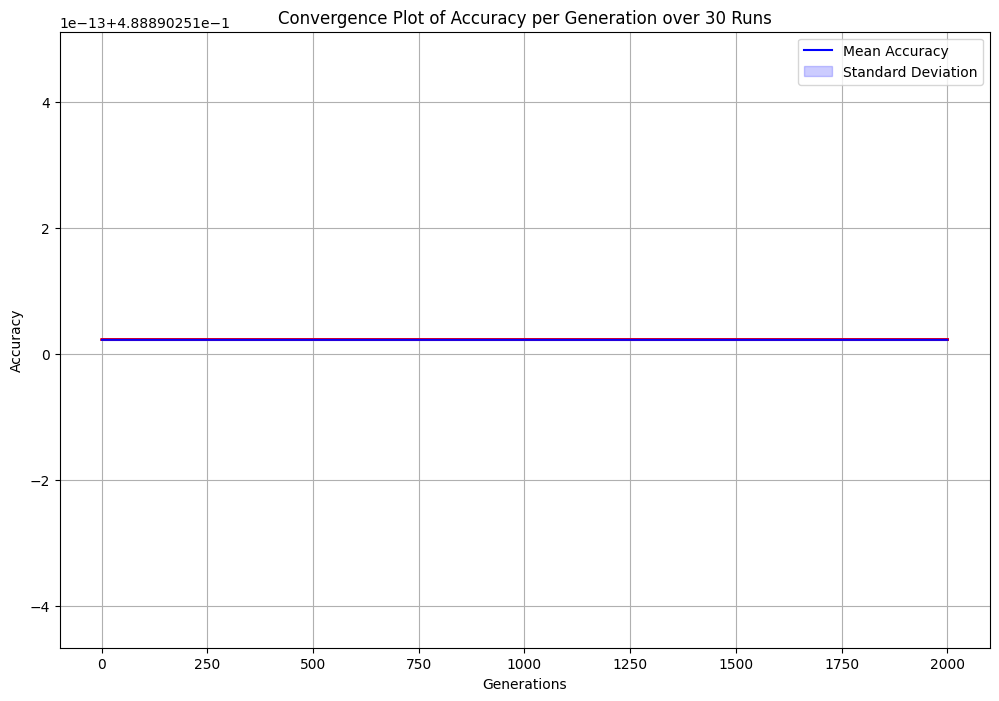

In [18]:
import matplotlib.pyplot as plt

# Determine the maximum number of generations across all runs
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = np.arange(1, max_generations + 1)

# Initialize a matrix to hold all fitness values, handling varying lengths
fitness_matrix = np.full((30, max_generations), np.nan)

for i, best_fitness_per_gen in enumerate(all_best_fitness):
    fitness_length = len(best_fitness_per_gen)
    fitness_matrix[i, :fitness_length] = best_fitness_per_gen

# Plot all runs in light gray
plt.figure(figsize=(12, 8))
for i in range(30):
    plt.plot(
        generations,
        fitness_matrix[i],
        linestyle='-',
        color='red',
        alpha=0.5
    )

# Compute the mean and standard deviation across runs at each generation
mean_fitness = np.nanmean(fitness_matrix, axis=0)
std_fitness = np.nanstd(fitness_matrix, axis=0)

# Plot the mean best fitness
plt.plot(
    generations,
    mean_fitness,
    linestyle='-',
    color='blue',
    label='Mean Accuracy'
)

# Fill the area between (mean - std) and (mean + std)
plt.fill_between(
    generations,
    mean_fitness - std_fitness,
    mean_fitness + std_fitness,
    color='blue',
    alpha=0.2,
    label='Standard Deviation'
)

plt.title('Convergence Plot of Accuracy per Generation over 30 Runs')
plt.xlabel('Generations')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()